In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt 
from imblearn.over_sampling import KMeansSMOTE
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from scipy import stats
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier,StackingClassifier ,IsolationForest,  AdaBoostClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score,cohen_kappa_score, classification_report
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance


In [4]:
df = pd.read_csv("Debernardi et al 2020 data.csv")
df.shape

(590, 14)

In [5]:
df.head()


,sample_id,patient_cohort,sample_origin,age,sex,diagnosis,stage,benign_sample_diagnosis,plasma_CA19_9,creatinine,LYVE1,REG1B,TFF1,REG1A
0,S1,Cohort1,BPTB,33,F,1,NaN,NaN,11.7,1.83222,0.893219,52.94884,654.282174,1262.000
1,S10,Cohort1,BPTB,81,F,1,NaN,NaN,NaN,0.97266,2.037585,94.46703,209.488250,228.407
2,S100,Cohort2,BPTB,51,M,1,NaN,NaN,7.0,0.78039,0.145589,102.36600,461.141000,NaN
3,S101,Cohort2,BPTB,61,M,1,NaN,NaN,8.0,0.70122,0.002805,60.57900,142.950000,NaN
4,S102,Cohort2,BPTB,62,M,1,NaN,NaN,9.0,0.21489,0.000860,65.54000,41.088000,NaN


In [6]:
df.describe




<bound method NDFrame.describe of     sample_id patient_cohort sample_origin  age sex  diagnosis stage  \
0          S1        Cohort1          BPTB   33   F          1   NaN   
1         S10        Cohort1          BPTB   81   F          1   NaN   
2        S100        Cohort2          BPTB   51   M          1   NaN   
3        S101        Cohort2          BPTB   61   M          1   NaN   
4        S102        Cohort2          BPTB   62   M          1   NaN   
..        ...            ...           ...  ...  ..        ...   ...   
585      S549        Cohort2          BPTB   68   M          3    IV   
586      S558        Cohort2          BPTB   71   F          3    IV   
587      S560        Cohort2          BPTB   63   M          3    IV   
588      S583        Cohort2          BPTB   75   F          3    IV   
589      S590        Cohort1          BPTB   74   M          3    IV   

    benign_sample_diagnosis  plasma_CA19_9  creatinine     LYVE1       REG1B  \
0                    

In [7]:
columns_ = df.columns.to_list()

df = df[["creatinine",
           "plasma_CA19_9",
          "age",
          "sex",
          "LYVE1",
          "REG1B",
          "TFF1",
          "REG1A",
          "diagnosis"]].copy()
df.sex =df.sex.map({"M":1 , "F": 0})
df.head()

,creatinine,plasma_CA19_9,age,sex,LYVE1,REG1B,TFF1,REG1A,diagnosis
0,1.83222,11.7,33,0,0.893219,52.94884,654.282174,1262.000,1
1,0.97266,NaN,81,0,2.037585,94.46703,209.488250,228.407,1
2,0.78039,7.0,51,1,0.145589,102.36600,461.141000,NaN,1
3,0.70122,8.0,61,1,0.002805,60.57900,142.950000,NaN,1
4,0.21489,9.0,62,1,0.000860,65.54000,41.088000,NaN,1


In [8]:
df.isna().sum()


creatinine         0
plasma_CA19_9    240
age                0
sex                0
LYVE1              0
REG1B              0
TFF1               0
REG1A            284
diagnosis          0
dtype: int64

In [9]:

from tabulate import tabulate

# List of feature columns
features = [ 'creatinine', 'plasma_CA19_9', 'age', 'sex', 'LYVE1', 'REG1B', 'TFF1', 'REG1A']

for index, feature in enumerate(features):
    print(f"Index: {index}, Feature: {feature}")
# Group by diagnosis type
grouped = df.groupby('diagnosis')

# Calculate min, max, and mean for each feature within each diagnosis category
stats = grouped[features].agg(['min', 'max', 'mean'])

# Flatten MultiIndex columns
stats.columns = ['_'.join(col).strip() for col in stats.columns.values]

# Reset index to turn 'diagnosis' back into a column
stats = stats.reset_index()

# Set 'diagnosis' as index to prepare for transpose
stats = stats.set_index('diagnosis')

# Transpose rows and columns
stats_t = stats.transpose()

# To make the output clearer, optionally reset index or rename columns
# For display, you might want to set 'diagnosis' as the header row
# and have features as rows, stats as columns

# Print the transposed table
print(tabulate(stats_t, headers='keys', tablefmt='grid'))

Index: 0, Feature: creatinine
Index: 1, Feature: plasma_CA19_9
Index: 2, Feature: age
Index: 3, Feature: sex
Index: 4, Feature: LYVE1
Index: 5, Feature: REG1B
Index: 6, Feature: TFF1
Index: 7, Feature: REG1A
+--------------------+---------------+---------------+----------------+
|                    |             1 |             2 |              3 |
+====================+===============+===============+================+
| creatinine_min     |    0.06786    |    0.05655    |     0.07917    |
+--------------------+---------------+---------------+----------------+
| creatinine_max     |    3.44955    |    3.33645    |     4.11684    |
+--------------------+---------------+---------------+----------------+
| creatinine_mean    |    0.797633   |    0.847929   |     0.916281   |
+--------------------+---------------+---------------+----------------+
| plasma_CA19_9_min  |    0          |    1          |     0.6        |
+--------------------+---------------+---------------+----------------+


C:\Users\Surface\AppData\Local\Temp\ipykernel_18872\1813333314.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='diagnosis', y=var, data=df, palette=custom_palette)


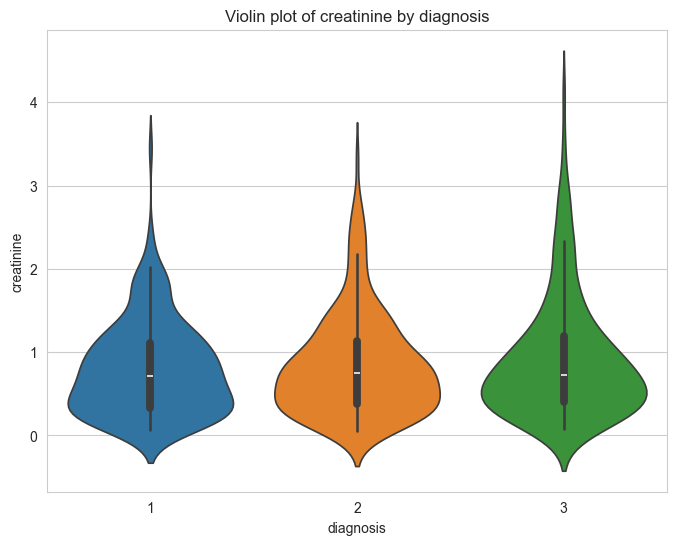

C:\Users\Surface\AppData\Local\Temp\ipykernel_18872\1813333314.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='diagnosis', y=var, data=df, palette=custom_palette)


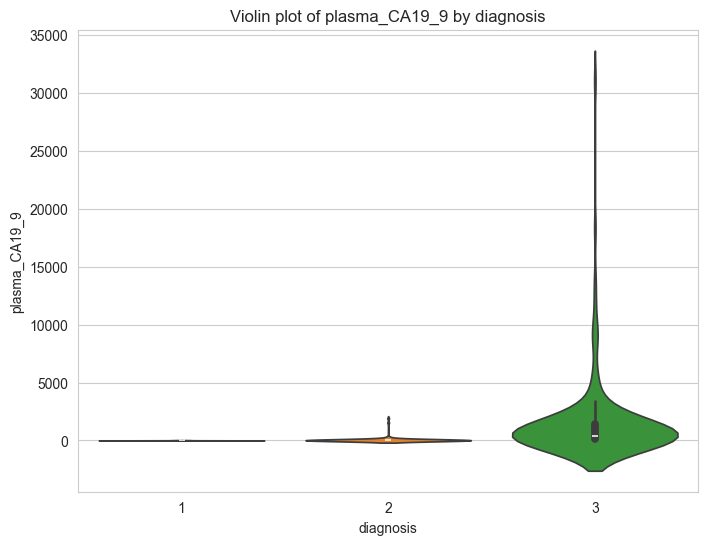

C:\Users\Surface\AppData\Local\Temp\ipykernel_18872\1813333314.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='diagnosis', y=var, data=df, palette=custom_palette)


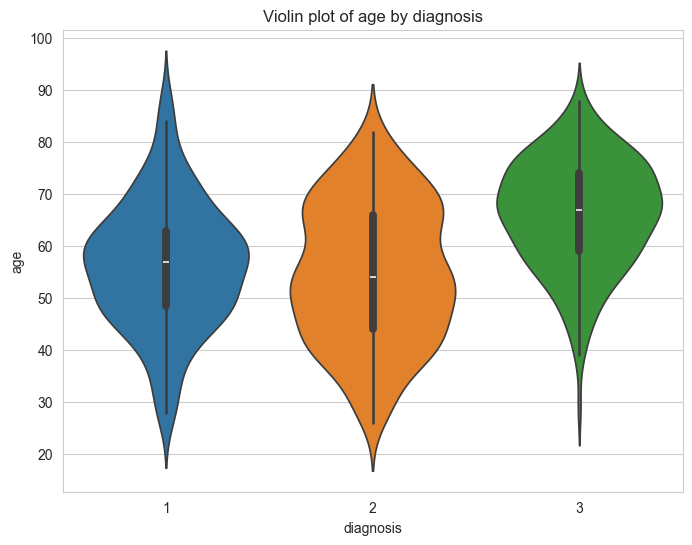

C:\Users\Surface\AppData\Local\Temp\ipykernel_18872\1813333314.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='diagnosis', y=var, data=df, palette=custom_palette)


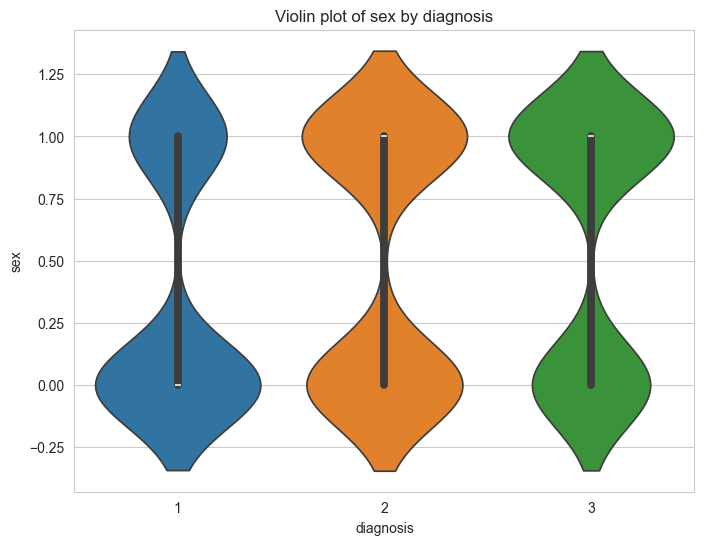

C:\Users\Surface\AppData\Local\Temp\ipykernel_18872\1813333314.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='diagnosis', y=var, data=df, palette=custom_palette)


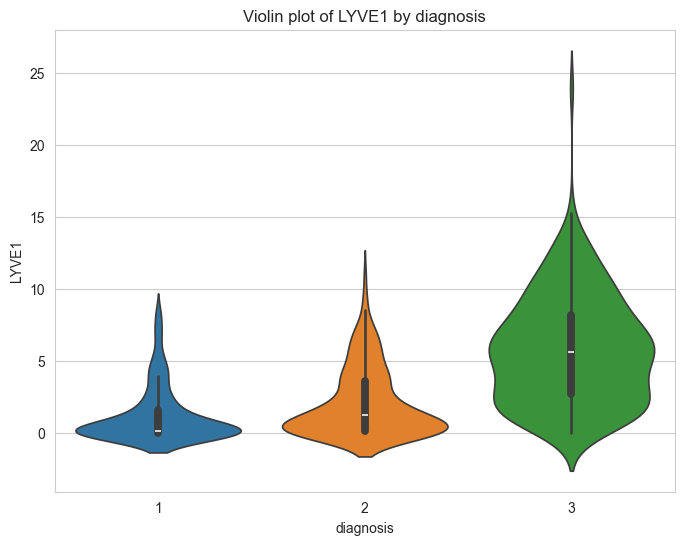

C:\Users\Surface\AppData\Local\Temp\ipykernel_18872\1813333314.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='diagnosis', y=var, data=df, palette=custom_palette)


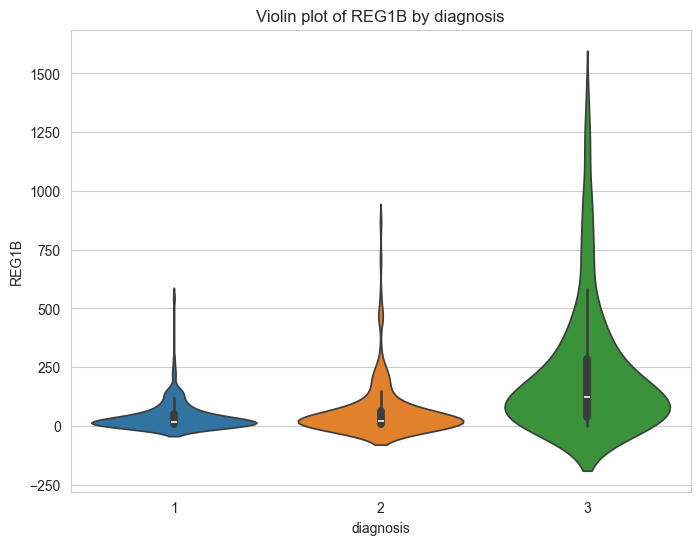

C:\Users\Surface\AppData\Local\Temp\ipykernel_18872\1813333314.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='diagnosis', y=var, data=df, palette=custom_palette)


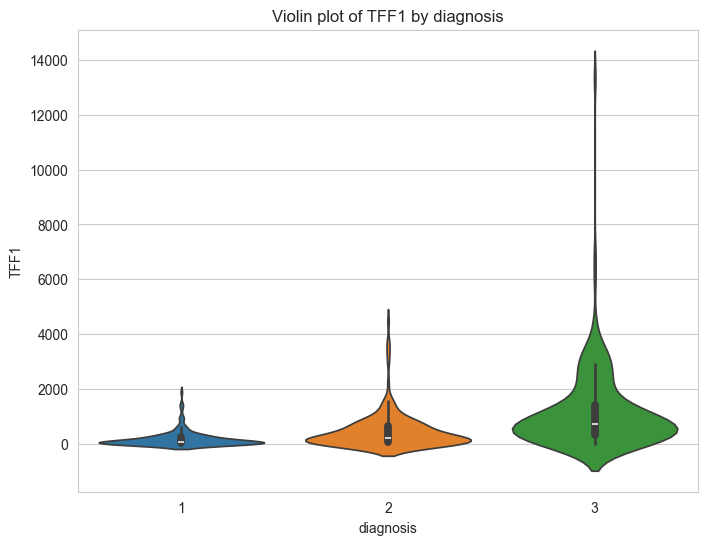

C:\Users\Surface\AppData\Local\Temp\ipykernel_18872\1813333314.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='diagnosis', y=var, data=df, palette=custom_palette)


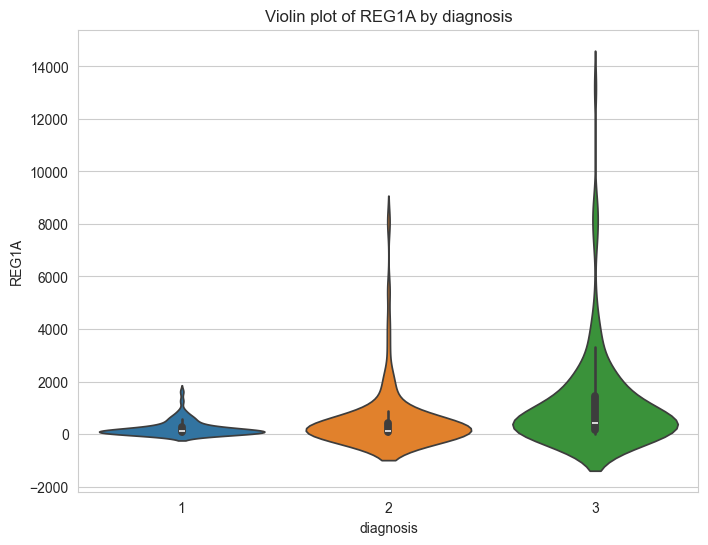

In [11]:

import seaborn as sns
import matplotlib.pyplot as plt

variables = ['creatinine', 'plasma_CA19_9', 'age', 'sex', 'LYVE1', 'REG1B', 'TFF1', 'REG1A']

# Define a custom palette with three colors
custom_palette = ['#1f77b4', '#ff7f0e', '#2ca02c']  # Blue, Orange, Green

for var in variables:
    plt.figure(figsize=(8, 6))
    sns.violinplot(x='diagnosis', y=var, data=df, palette=custom_palette)
    plt.title(f'Violin plot of {var} by diagnosis')
    plt.show()

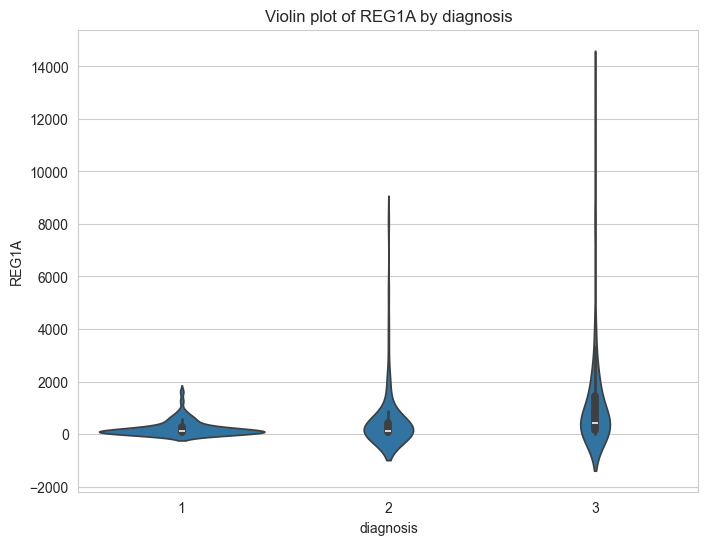

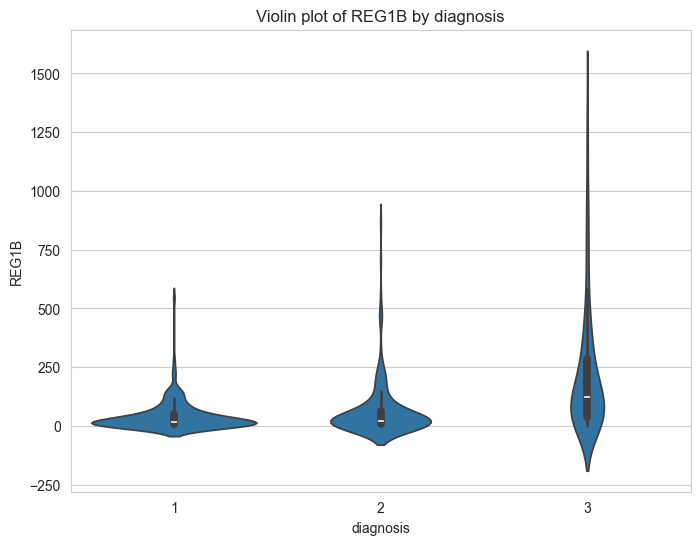

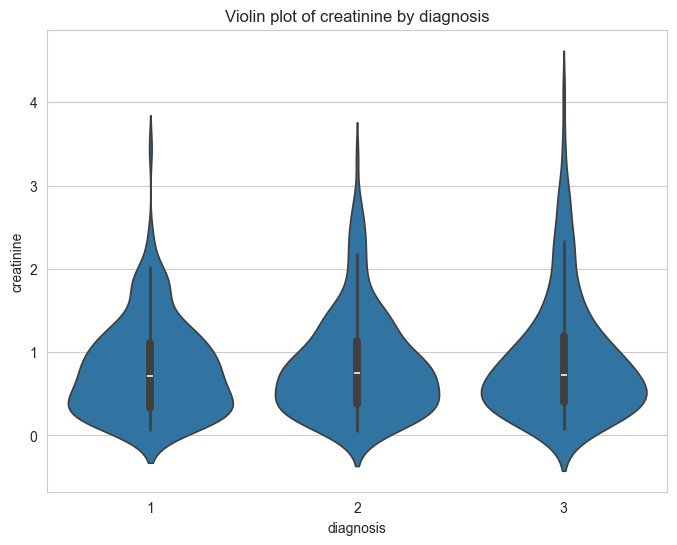

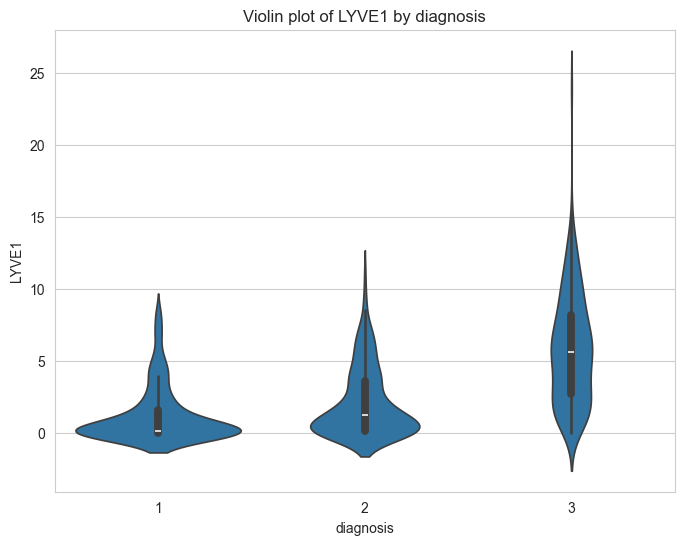

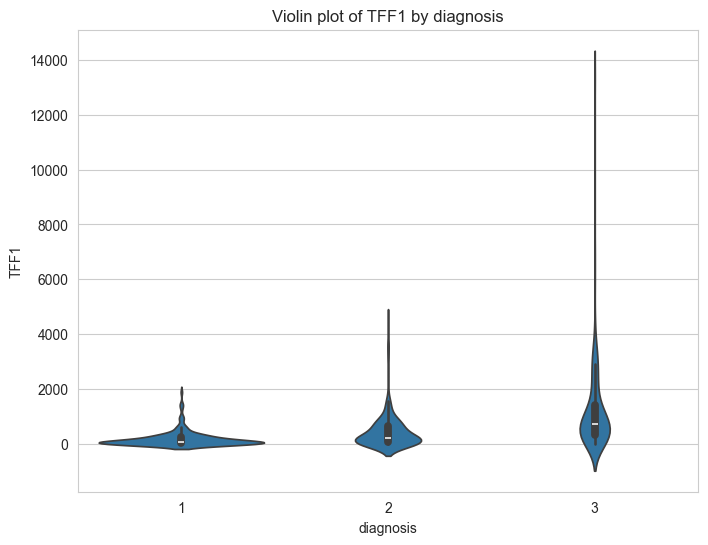

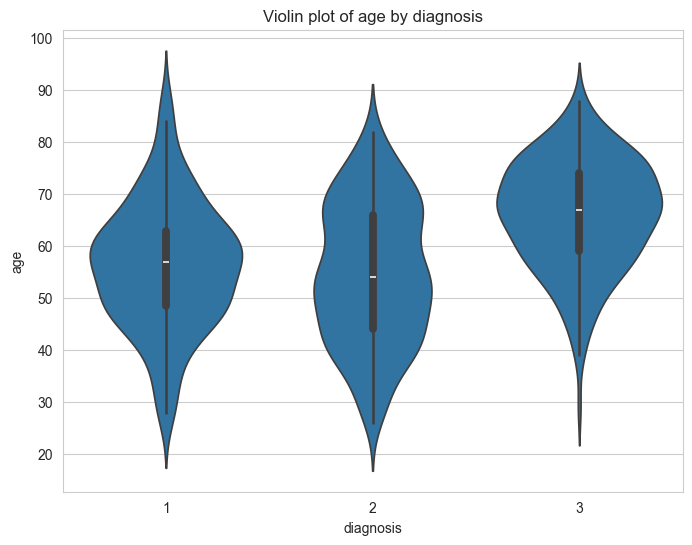

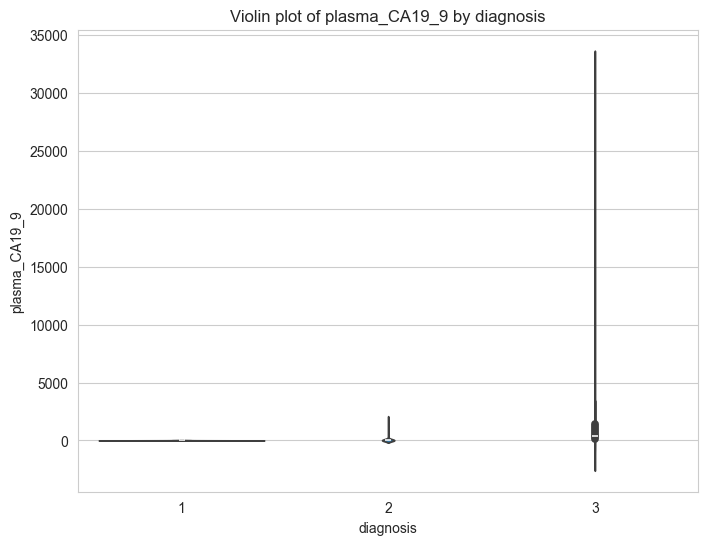

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

variables = ['REG1A', 'REG1B', 'creatinine', 'LYVE1', 'TFF1', 'age', 'plasma_CA19_9']
for var in variables:
    plt.figure(figsize=(8, 6))
    sns.violinplot(x='diagnosis', y=var, data=df)
    plt.title(f'Violin plot of {var} by diagnosis')
    plt.show()


In [13]:
mean_plasma_diagnosis_1 = df.loc[df['diagnosis'] == 1, 'plasma_CA19_9'].mean()
mean_plasma_diagnosis_2 = df.loc[df['diagnosis'] == 2, 'plasma_CA19_9'].mean()
mean_plasma_diagnosis_3 =df.loc[df["diagnosis"]== 3, 'plasma_CA19_9'].mean()
df.loc[(df['diagnosis'] == 1) & (df['plasma_CA19_9'].isna()), 'plasma_CA19_9'] = mean_plasma_diagnosis_1
df.loc[(df['diagnosis'] == 2) & (df['plasma_CA19_9'].isna()), 'plasma_CA19_9'] = mean_plasma_diagnosis_2
df.loc[(df['diagnosis'] == 3) & (df['plasma_CA19_9'].isna()), 'plasma_CA19_9'] = mean_plasma_diagnosis_3
mean_reg1a_diagnosis_1 = df.loc[df['diagnosis'] == 1, 'REG1A'].mean()
mean_reg1a_diagnosis_2 = df.loc[df['diagnosis'] == 2, 'REG1A'].mean()
mean_reg1a_diagnosis_3 =df.loc[df["diagnosis"]== 3, 'REG1A'].mean()
df.loc[(df['diagnosis'] == 1) & (df['REG1A'].isna()), 'REG1A'] = mean_reg1a_diagnosis_1
df.loc[(df['diagnosis'] == 2) & (df['REG1A'].isna()), 'REG1A'] = mean_reg1a_diagnosis_2
df.loc[(df['diagnosis'] == 3) & (df['REG1A'].isna()), 'REG1A'] = mean_reg1a_diagnosis_3

In [14]:
import pandas as pd

# Assuming 'df' is your DataFrame
# Filter numeric columns
numeric_cols = df.select_dtypes(include='number').columns

# Compute mean only on numeric columns grouped by 'diagnosis'
diagnosis = df.groupby('diagnosis')[numeric_cols].mean()

# Optional: highlight max values
diagnosis.style.highlight_max()

,creatinine,plasma_CA19_9,age,sex,LYVE1,REG1B,TFF1,REG1A,diagnosis
diagnosis,,,,,,,,,
1,0.797633,8.749569,56.333333,0.371585,1.212887,41.327901,169.024140,227.871886,1.000000
2,0.847929,61.785741,54.701923,0.514423,2.084612,64.174510,448.256897,547.458092,2.000000
3,0.916281,1476.154733,66.180905,0.582915,5.788567,226.308587,1148.611527,1138.323721,3.000000


In [15]:
df.describe
df.age

0      33
1      81
2      51
3      61
4      62
       ..
585    68
586    71
587    63
588    75
589    74
Name: age, Length: 590, dtype: int64

In [16]:
# Cleaning by Z-scores
from scipy import stats

z_scores = stats.zscore(df.select_dtypes(include=['float64', 'int64']))
abs_z_scores = abs(z_scores)

# Define a threshold 
threshold = 3
# Identify outliers
outliers = (abs_z_scores > threshold)

# If you want to see which rows are outliers
outlier_rows = df[(outliers).any(axis=1)]

print(outlier_rows)


# Define a threshold
threshold = 5
df_cleaned = df[(abs_z_scores < threshold).all(axis=1)]

print(df_cleaned)
df_cleaned.isna().sum()

     creatinine  plasma_CA19_9  age  sex      LYVE1        REG1B  \
144     3.44955       8.749569   48    0   4.512589   138.798730   
210     1.13100       9.000000   73    1   4.860454   704.236000   
257     1.17624      73.000000   67    1   2.373931     9.158758   
272     3.33645      61.785741   31    1   0.073313    12.445650   
289     2.79357      20.000000   44    1   3.870352    34.417047   
317     1.86615      61.785741   54    0   6.913633   864.366930   
322     1.30065      61.785741   48    1   3.067997   459.057900   
359     1.00659       7.900000   40    1   1.566210   128.280180   
399     0.96135       0.600000   56    1   8.167554   535.281600   
408     0.68991    1476.154733   53    1  11.954790   682.898790   
410     1.05183    1476.154733   54    1  10.956950  1293.819450   
422     0.29406       6.000000   48    1   3.530855  1124.108000   
427     0.13572   31000.000000   69    1   7.786741   222.366130   
474     1.51554      33.000000   79    0  11.210

creatinine       0
plasma_CA19_9    0
age              0
sex              0
LYVE1            0
REG1B            0
TFF1             0
REG1A            0
diagnosis        0
dtype: int64

In [17]:
from sklearn.model_selection import train_test_split
#X , y
X = df_cleaned.drop(columns=["diagnosis"])
y = df_cleaned["diagnosis"]
# Split the data 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42)

print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(487, 8)
(487,)
(86, 8)
(86,)


In [18]:

from imblearn.over_sampling import ADASYN

adasyn = ADASYN(random_state=42)
X_resampled, y_resampled = adasyn.fit_resample(X_train, y_train)
print("Original class distribution:", y_train.value_counts())
print("Resampled class distribution:", pd.Series(y_resampled).value_counts())
print("Shape of X_resampled:", X_resampled.shape)
print("Shape of y_resampled:", y_resampled.shape)

Original class distribution: diagnosis
2    177
3    158
1    152
Name: count, dtype: int64
Resampled class distribution: diagnosis
2    177
1    170
3    165
Name: count, dtype: int64
Shape of X_resampled: (512, 8)
Shape of y_resampled: (512,)


In [23]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

def whale_optimizer_feature_selection(X, y, n_select=6, n_particles=20, max_iter=20, random_state=42):
    np.random.seed(random_state)
    n_features = X.shape[1]

    # Initialize population: each with exactly n_select features
    population = np.zeros((n_particles, n_features), dtype=int)
    for i in range(n_particles):
        selected = np.random.choice(n_features, n_select, replace=False)
        population[i, selected] = 1

    clf = RandomForestClassifier(n_jobs=-1, class_weight='balanced', max_depth=5, random_state=42)

    def fitness(solution, cache):
        # Cache based on a tuple of indices
        key = tuple(np.where(solution == 1)[0])
        if key in cache:
            return cache[key]
        selected_indices = np.array(key)
        if len(selected_indices) == 0:
            cache[key] = 0
            return 0
        X_subset = X.iloc[:, selected_indices]
        scores = cross_val_score(clf, X_subset, y, cv=3, scoring='accuracy')
        mean_score = scores.mean()
        cache[key] = mean_score
        return mean_score

    best_solution = None
    best_fitness = -np.inf
    cache = {}  # cache for fitness evaluations

    for iteration in range(max_iter):
        # Evaluate all particles
        fitness_scores = np.array([fitness(sol, cache) for sol in population])
        max_idx = np.argmax(fitness_scores)
        if fitness_scores[max_idx] > best_fitness:
            best_fitness = fitness_scores[max_idx]
            best_solution = population[max_idx].copy()

        # Update particles
        for i in range(n_particles):
            # Flip bits with probability 0.2
            flip_mask = np.random.rand(n_features) < 0.2
            population[i] = np.abs(population[i] - flip_mask.astype(int))

            # Adjust to maintain exactly n_select features
            current_sum = np.sum(population[i])
            if current_sum > n_select:
                # Deselect random selected features
                indices = np.where(population[i] == 1)[0]
                to_deselect = np.random.choice(indices, current_sum - n_select, replace=False)
                population[i, to_deselect] = 0
            elif current_sum < n_select:
                # Select random unselected features
                zeros = np.where(population[i] == 0)[0]
                to_select = np.random.choice(zeros, n_select - current_sum, replace=False)
                population[i, to_select] = 1

    selected_indices = np.where(best_solution == 1)[0]
    return selected_indices


n_features = X_resampled.shape[1]
selected_indices = whale_optimizer_feature_selection(X_resampled, y_resampled, n_select=6, n_particles=20, max_iter=20)
#selected features
feature_names = list(X_resampled.columns)
selected_feature_names = [feature_names[i] for i in selected_indices]

print("Selected feature indices:", list(selected_indices))
print("Selected features:", selected_feature_names)

# Create dataset with selected features
X_selected = X_resampled.iloc[:, selected_indices]
print(X_selected.head())


Selected feature indices: [0, 1, 2, 3, 5, 7]
Selected features: ['creatinine', 'plasma_CA19_9', 'age', 'sex', 'REG1B', 'REG1A']
   creatinine  plasma_CA19_9  age  sex      REG1B        REG1A
0     0.61074      24.000000   56    0   83.92800   227.871886
1     0.09048    1476.154733   67    0   29.13800  1138.323721
2     3.33645      61.785741   31    1   12.44565    75.094000
3     1.56078    2114.000000   70    1  788.08725  3658.172000
4     0.29406       5.025272   57    0    8.23218   227.871886


In [25]:
new_X = X_resampled.iloc[:, selected_indices]
new_y = y_resampled
print(new_X.head())

   creatinine  plasma_CA19_9  age  sex      REG1B        REG1A
0     0.61074      24.000000   56    0   83.92800   227.871886
1     0.09048    1476.154733   67    0   29.13800  1138.323721
2     3.33645      61.785741   31    1   12.44565    75.094000
3     1.56078    2114.000000   70    1  788.08725  3658.172000
4     0.29406       5.025272   57    0    8.23218   227.871886


C:\Users\Surface\AppData\Roaming\Python\Python312\site-packages\xgboost\training.py:183: UserWarning: [10:19:54] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Results for XGBoost:
Training Time: 0.51 seconds
Prediction Time: 0.03 seconds
ROC AUC: 0.960
Accuracy: 0.818
Precision: 0.832
Recall: 0.816
F1 Score: 0.819
Cohen's Kappa: 0.726
Classification Report:
               precision    recall  f1-score   support

           1       0.91      0.84      0.88        25
           2       0.73      0.89      0.80        27
           3       0.86      0.72      0.78        25

    accuracy                           0.82        77
   macro avg       0.83      0.82      0.82        77
weighted avg       0.83      0.82      0.82        77



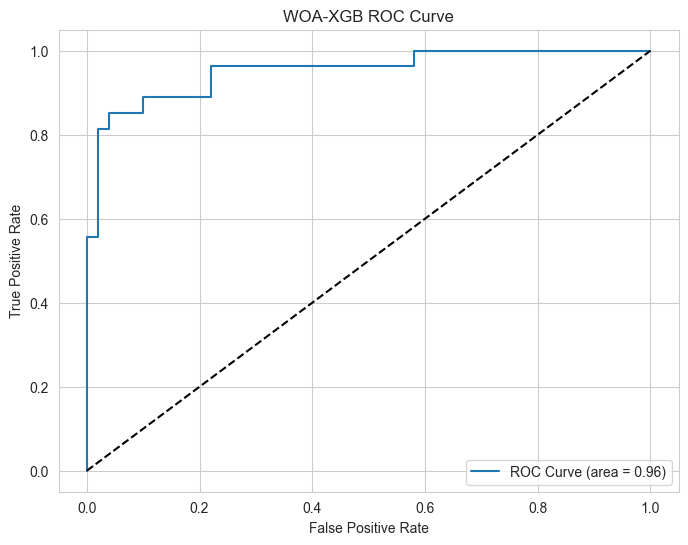

TypeError: heatmap() missing 1 required positional argument: 'data'

<Figure size 800x600 with 0 Axes>

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, 
    cohen_kappa_score, confusion_matrix, classification_report, roc_curve, auc
)
from sklearn.inspection import permutation_importance
from scipy.stats import pearsonr
import shap
import lime
import lime.lime_tabular
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder


# Split data
X_train, X_test, y_train, y_test = train_test_split(
    new_X, new_y, test_size=0.15, random_state=42, stratify=new_y
)

# Encode target variable if categorical
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

# Initialize XGBoost model
xgb_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

# Measure execution time for training
start_time = time.time()
xgb_model.fit(X_train, y_train_encoded)
training_time = time.time() - start_time

# Predictions
start_time = time.time()
y_pred = xgb_model.predict(X_test)
y_pred_proba = xgb_model.predict_proba(X_test)
prediction_time = time.time() - start_time

# Metrics
roc_auc = roc_auc_score(y_test_encoded, y_pred_proba, multi_class='ovr')
accuracy = accuracy_score(y_test_encoded, y_pred)
precision = precision_score(y_test_encoded, y_pred, average='macro')
recall = recall_score(y_test_encoded, y_pred, average='macro')
f1 = f1_score(y_test_encoded, y_pred, average='macro')
kappa = cohen_kappa_score(y_test_encoded, y_pred)

# Confusion matrix and classification report
clf_report = classification_report(
    y_test_encoded,
    y_pred,
    target_names=[str(c) for c in le.classes_]
)

# **Permutation importance for p-values approximation**
perm_importance = permutation_importance(xgb_model, X_test, y_test_encoded, n_repeats=10, random_state=42)
importance_means = perm_importance.importances_mean
importance_std = perm_importance.importances_std

#
p_values = []
for i in range(X_test.shape[1]):
    corr, p_val = pearsonr(X_test.iloc[:, i], y_test_encoded)
    p_values.append(p_val)

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns

# --- Model Evaluation Metrics ---
print("Results for XGBoost:")
print(f"Training Time: {training_time:.2f} seconds")
print(f"Prediction Time: {prediction_time:.2f} seconds")
print(f"ROC AUC: {roc_auc:.3f}")
print(f"Accuracy: {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall: {recall:.3f}")
print(f"F1 Score: {f1:.3f}")
print(f"Cohen's Kappa: {kappa:.3f}")

print("Classification Report:\n", clf_report)

# --- Plot ROC Curve ---
fpr, tpr, thresholds = roc_curve(y_test_encoded, y_pred_proba[:, 1], pos_label=1)
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'ROC Curve (area = {roc_auc:.2f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('WOA-XGB ROC Curve')
plt.legend(loc='lower right')
plt.show()

# --- Confusion Matrix Heatmap ---
plt.figure(figsize=(8,6))
sns.heatmap( annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# --- P-values Table ---
pval_df = pd.DataFrame({
    'Feature': X_test.columns,
    'P-value': p_values,
    'Importance Mean': importance_means,
    'Importance Std': importance_std
}).sort_values(by='P-value')

print("Feature P-values and Importance:")
print(pval_df)

# --- SHAP Analysis ---
print("woa-gbx SHAP analysis for XGBoost")
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

# Summary Plot (Bar)
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.suptitle("WOA-XGB SHAP Summary Bar Plot", fontsize=16)
plt.show()









In [28]:
# Import necessary libraries
from sklearn.model_selection import cross_val_score
from skopt import BayesSearchCV
from skopt.space import Real, Integer
from xgboost import XGBClassifier
from sklearn.ensemble import AdaBoostClassifier, VotingClassifier

import numpy as np

# Map original labels [1, 2, 3] to [0, 1, 2]
label_mapping = {1: 0, 2: 1, 3: 2}
y_train_mapped = np.array([label_mapping[label] for label in y_train])

# Define the hyperparameter search spaces for each classifier

from skopt.space import Categorical

xgb_search_space = {
    'n_estimators': Integer(50, 500),
    'max_depth': Integer(3, 10),
    'learning_rate': Real(0.01, 0.3, prior='log-uniform'),
    'subsample': Real(0.5, 1.0),
    'colsample_bytree': Real(0.5, 1.0),
    'use_label_encoder': Categorical([True, False])
}

adaboost_search_space = {
    'n_estimators': Integer(50, 500),
    'learning_rate': Real(0.01, 1.0),
    'algorithm': ['SAMME', 'SAMME.R']
}

# For ensemble classifier, tune weights or base estimators as needed
# Here, as an example, we tune the weights for voting classifier
ensemble_search_space = {
    'weights': [[w1, w2] for w1 in range(1, 5) for w2 in range(1, 5)]
}

# Initialize classifiers with default parameters
xgb = XGBClassifier(use_label_encoder=True, eval_metric='logloss')
adaboost = AdaBoostClassifier()

# Set up Bayesian optimization with cross-validation
xgb_bayes = BayesSearchCV(xgb, xgb_search_space, n_iter=50, scoring='accuracy', cv=5, random_state=42)
adaboost_bayes = BayesSearchCV(adaboost, adaboost_search_space, n_iter=50, scoring='accuracy', cv=5, random_state=42)

# F
xgb_bayes.fit(X_train, y_train_mapped)

adaboost_bayes.fit(X_train, y_train_mapped)

# Retrieve best estimators
best_xgb = xgb_bayes.best_estimator_
best_adaboost = adaboost_bayes.best_estimator_

# (Optional) Build ensemble classifier with tuned models
ensemble_clf = VotingClassifier(estimators=[
    ('xgb', best_xgb),
    ('adb', best_adaboost)
], voting='soft', weights=[1, 1])  # Adjust weights if tuning

# Fit ensemble classifier
ensemble_clf.fit(X_train, y_train_mapped)

# After training, per

C:\Users\Surface\AppData\Roaming\Python\Python312\site-packages\xgboost\training.py:183: UserWarning: [10:30:36] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\Surface\AppData\Roaming\Python\Python312\site-packages\xgboost\training.py:183: UserWarning: [10:30:37] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\Surface\AppData\Roaming\Python\Python312\site-packages\xgboost\training.py:183: UserWarning: [10:30:38] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\Surface\AppData\Roaming\Python\Python312\site-packages\xgboost\training.py:183: UserWarning: [10:30:39] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\

KeyboardInterrupt: 

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    cohen_kappa_score,
    confusion_matrix,
    classification_report,
    precision_recall_curve,
    average_precision_score,
    
)
from sklearn.model_selection import train_test_split
import seaborn as sns
import scipy.stats as stats


# 1. MCC
# Correct usage
y_pred = xgb_model.predict(X_test)
print("Predictions shape:", y_pred.shape)
print("True labels shape:", y_test_encoded.shape)

# Now compute MCC
from sklearn.metrics import matthews_corrcoef
mcc = matthews_corrcoef(y_test_encoded, y_pred)
print("Matthews Correlation Coefficient (MCC):", mcc)

Predictions shape: (77,)
True labels shape: (77,)
Matthews Correlation Coefficient (MCC): 0.908082266131134


In [29]:
# 4. Compute p-value for MCC via permutation test
def permutation_test_metric(y_true, y_pred, metric_func, n_permutations=1000):
    observed = metric_func(y_true, y_pred)
    permuted_scores = []
    for _ in range(n_permutations):
        y_perm = np.random.permutation(y_true)
        perm_score = metric_func(y_perm, y_pred)
        permuted_scores.append(perm_score)
    p_value = np.mean(np.array(permuted_scores) >= observed)
    return p_value

p_value_mcc = permutation_test_metric(y_test_encoded, y_pred, matthews_corrcoef)
print(f"Permutation p-value for MCC: {p_value_mcc:.4f}")

# Similarly, p-value for Cohen's Kappa
p_value_kappa = permutation_test_metric(y_test_encoded, y_pred, cohen_kappa_score)
print(f"Permutation p-value for Cohen's Kappa: {p_value_kappa:.4f}")

# 5. Confusion matrix heatmap
plt.figure(figsize=(8,6))
cm = confusion_matrix(y_test_encoded, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# 6. Optional: add metrics summary table
import pandas as pd
metrics_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision (macro)', 'Recall (macro)', 'F1 Score (macro)', 'MCC', "Cohen's Kappa"],
    'Value': [
        accuracy_score(y_test_encoded, y_pred),
        precision_score(y_test_encoded, y_pred, average='macro'),
        recall_score(y_test_encoded, y_pred, average='macro'),
        f1_score(y_test_encoded, y_pred, average='macro'),
        mcc,
       
    ],
    'p-value MCC': [np.nan, np.nan, np.nan, np.nan, p_value_mcc, np.nan],
    'p-value Kappa': [np.nan, np.nan, np.nan, np.nan, np.nan, p_value_kappa]
})
print(metrics_df)

NameError: name 'matthews_corrcoef' is not defined

In [31]:
import numpy as np
import lime
import lime.lime_tabular

# Set the sample index
sample_idx = 0  # change as needed

# Initialize the LIME explainer
explainer_lime = lime.lime_tabular.LimeTabularExplainer(
    training_data=np.array(X_train),
    feature_names=X_train.columns,
    class_names=le.classes_,
    mode='classification'
)

# Ensure the data_row is a numpy array of feature values
data_row = X_test.iloc[sample_idx].values

# Generate explanation
exp = explainer_lime.explain_instance(
    data_row=data_row,
    predict_fn=xgb_model.predict_proba,
    num_features=10
)

# Plot LIME explanation in notebook
exp.show_in_notebook(show_table=True)

# Save explanation to HTML file
html_path = f"lime_explanation_sample_{sample_idx}.html"
exp.save_to_file(html_path)
print(f"LIME explanation saved to {html_path}")


LIME explanation saved to lime_explanation_sample_0.html


In [32]:

# Violin Plot for SHAP values (-1 to 1)
# For illustration, plot for top 2 features
top_features_idx = np.argsort(np.abs(shap_values).mean(0))[-2:]
for idx in top_features_idx:
    feature_name = X_test.columns[idx]
    shap_vals = shap_values[:, idx]
    plt.figure(figsize=(8,4))
    sns.violinplot(x=shap_vals, inner='quartile', cut=0)
    plt.xlim(-1, 1)
    plt.xlabel(f'SHAP values for {feature_name}')
    plt.title(f'Violin Plot of SHAP values for {feature_name}')
    plt.show()

# --- Dependence Plots for Top Features ---
for feature_idx in top_features_idx:
    shap.dependence_plot(feature_idx, shap_values, X_test, show=False)
    feature_name = X_test.columns[feature_idx]
    plt.suptitle(f"Dependence Plot: {feature_name} (woa-gbx)", fontsize=14)
    plt.show()

NameError: name 'shap_values' is not defined

Predicted probabilities shape: (77, 3)
Training Time: 0.45 seconds
Prediction Time: 0.11 seconds
ROC AUC: 0.990
Accuracy: 0.935
Precision: 0.948
Recall: 0.933
F1 Score: 0.935
Cohen's Kappa: 0.902
Classification Report:
               precision    recall  f1-score   support

           1       1.00      0.80      0.89        25
           2       0.84      1.00      0.92        27
           3       1.00      1.00      1.00        25

    accuracy                           0.94        77
   macro avg       0.95      0.93      0.93        77
weighted avg       0.95      0.94      0.93        77



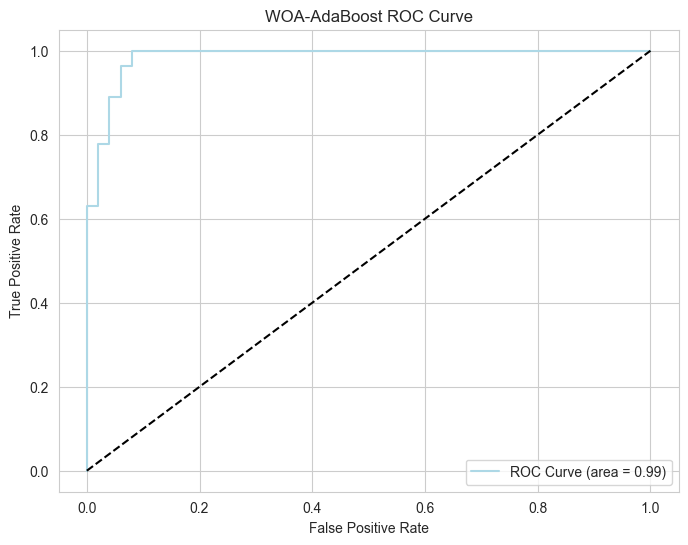

SHAP analysis for WOA-AdaBoost


  0%|          | 0/77 [00:00<?, ?it/s]

C:\Users\Surface\AppData\Local\Temp\ipykernel_21404\81453223.py:82: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test)
C:\Users\Surface\AppData\Local\Programs\Python\Python312\Lib\site-packages\shap\plots\_beeswarm.py:726: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(
C:\Users\Surface\AppData\Local\Programs\Python\Python312\Lib\site-packages\shap\plots\_beeswarm.py:746: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this wa

<Figure size 640x480 with 0 Axes>

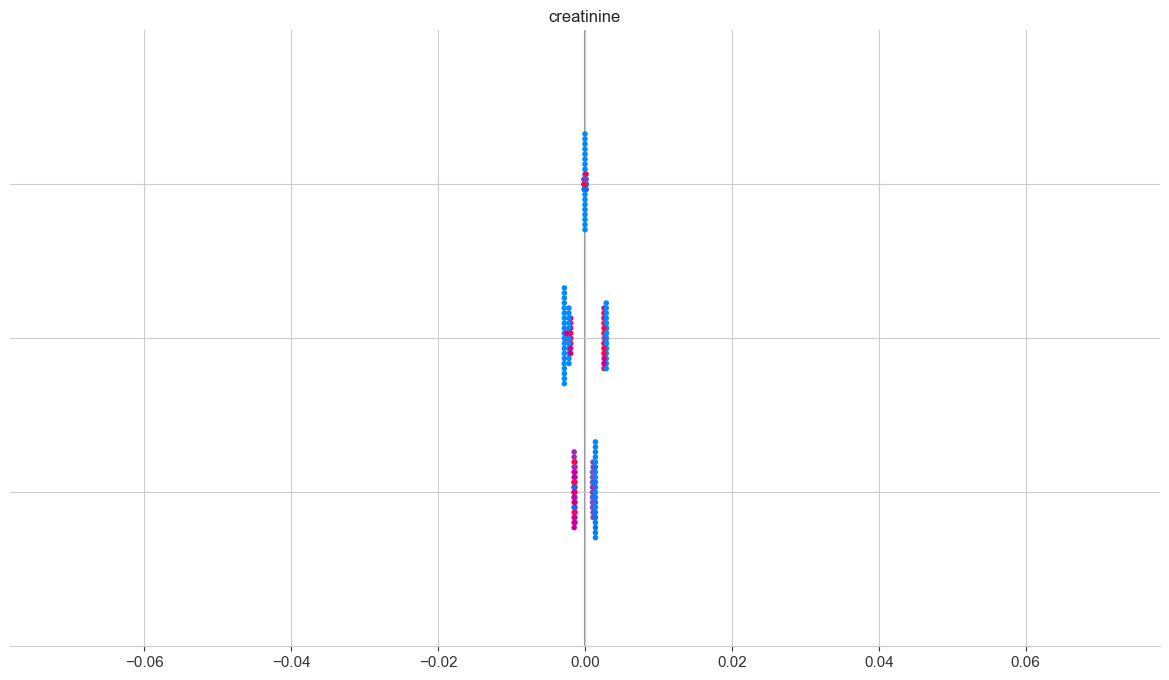

C:\Users\Surface\AppData\Local\Temp\ipykernel_21404\81453223.py:86: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)


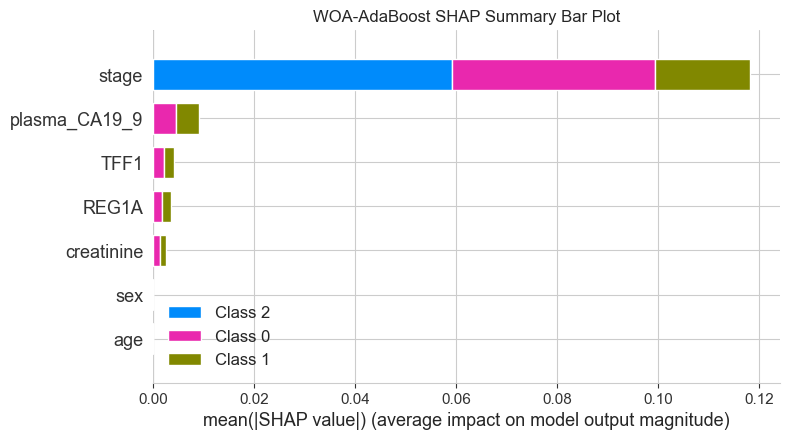

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

In [33]:
#adaboost
import numpy as np
import time
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, cohen_kappa_score, confusion_matrix, classification_report
from sklearn.ensemble import AdaBoostClassifier
from sklearn.preprocessing import LabelEncoder
import shap
import matplotlib.pyplot as plt

# Assuming new_X and new_y are already defined from your feature selection

# Split data
X_train, X_test, y_train, y_test = train_test_split(new_X, new_y, test_size=0.15, random_state=42, stratify=new_y)

# Encode target variable if it's categorical
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

# Initialize AdaBoostClassifier
ada_model = AdaBoostClassifier(
    n_estimators=100,          # You can tune this parameter
    learning_rate=1.0,         # You can tune this parameter
    random_state=42
)
# Measure execution time for training
start_time = time.time()
ada_model.fit(X_train, y_train_encoded)
training_time = time.time() - start_time

# Predictions
start_time = time.time()
y_pred = ada_model.predict(X_test)
y_pred_proba = ada_model.predict_proba(X_test)
prediction_time = time.time() - start_time

# and then compute roc_curve with y_test and y_pred_proba

# Check shape of predicted probabilities
print("Predicted probabilities shape:", y_pred_proba.shape)

# Compute ROC AUC
roc_auc = roc_auc_score(y_test_encoded, y_pred_proba, multi_class='ovr')
print(f"Training Time: {training_time:.2f} seconds")
print(f"Prediction Time: {prediction_time:.2f} seconds")
print(f"ROC AUC: {roc_auc:.3f}")
print(f"Accuracy: {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall: {recall:.3f}")
print(f"F1 Score: {f1:.3f}")
print(f"Cohen's Kappa: {kappa:.3f}")

print("Classification Report:\n", clf_report)

# --- Plot ROC Curve ---

fpr, tpr, thresholds = roc_curve(y_test_encoded, y_pred_proba[:, 1], pos_label=1)
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'ROC Curve (area = {roc_auc:.2f})', color='lightblue')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('WOA-AdaBoost ROC Curve')
plt.legend(loc='lower right')
plt.show()


# SHAP analysis
print("SHAP analysis for WOA-AdaBoost")

# Create a background dataset for KernelExplainer
background = X_train.sample(100, random_state=42)

explainer = shap.KernelExplainer(ada_model.predict_proba, background)

# Compute SHAP values
shap_values = explainer.shap_values(X_test, nsamples=100)

# Plot SHAP summary
shap.summary_plot(shap_values, X_test)


# Plot SHAP summary bar plot
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title("WOA-AdaBoost SHAP Summary Bar Plot")
plt.show()

# Dependence plots for top features
mean_abs_shap = np.abs(shap_values).mean(0)
top_features = np.argsort(mean_abs_shap)[-3:]
for feature_idx in top_features:
    shap.dependence_plot(feature_idx, shap_values, X_test)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    cohen_kappa_score,
    confusion_matrix,
    classification_report,
    precision_recall_curve,
    average_precision_score,
    
)
from sklearn.model_selection import train_test_split
import seaborn as sns
import scipy.stats as stats


# 1. MCC
# Correct usage
y_pred = ada_model.predict(X_test)
print("Predictions shape:", y_pred.shape)
print("True labels shape:", y_test_encoded.shape)

# Now compute MCC
from sklearn.metrics import matthews_corrcoef
mcc = matthews_corrcoef(y_test_encoded, y_pred)
print("Matthews Correlation Coefficient (MCC):", mcc)

In [ ]:
# 4. Compute p-value for MCC via permutation test
def permutation_test_metric(y_true, y_pred, metric_func, n_permutations=1000):
    observed = metric_func(y_true, y_pred)
    permuted_scores = []
    for _ in range(n_permutations):
        y_perm = np.random.permutation(y_true)
        perm_score = metric_func(y_perm, y_pred)
        permuted_scores.append(perm_score)
    p_value = np.mean(np.array(permuted_scores) >= observed)
    return p_value

p_value_mcc = permutation_test_metric(y_test_encoded, y_pred, matthews_corrcoef)
print(f"Permutation p-value for MCC: {p_value_mcc:.4f}")

# Similarly, p-value for Cohen's Kappa
p_value_kappa = permutation_test_metric(y_test_encoded, y_pred, cohen_kappa_score)
print(f"Permutation p-value for Cohen's Kappa: {p_value_kappa:.4f}")

# 5. Confusion matrix heatmap
plt.figure(figsize=(8,6))
cm = confusion_matrix(y_test_encoded, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# 6. Optional: add metrics summary table
import pandas as pd
metrics_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision (macro)', 'Recall (macro)', 'F1 Score (macro)', 'MCC', "Cohen's Kappa"],
    'Value': [
        accuracy_score(y_test_encoded, y_pred),
        precision_score(y_test_encoded, y_pred, average='macro'),
        recall_score(y_test_encoded, y_pred, average='macro'),
        f1_score(y_test_encoded, y_pred, average='macro'),
        mcc,
       
    ],
    'p-value MCC': [np.nan, np.nan, np.nan, np.nan, p_value_mcc, np.nan],
    'p-value Kappa': [np.nan, np.nan, np.nan, np.nan, np.nan, p_value_kappa]
})
print(metrics_df)

In [34]:
# --- LIME Explanation for a Single Sample ---
# Select a sample from test set
sample_idx = 0  # change as needed
explainer_lime = lime.lime_tabular.LimeTabularExplainer(
    training_data=np.array(X_train),
    feature_names=X_train.columns,
    class_names=le.classes_,
    mode='classification'
)

exp = explainer_lime.explain_instance(
    data_row=X_test.iloc[sample_idx],
    predict_fn=ada_model.predict_proba,
    num_features=10
)

# Plot LIME explanation
exp.show_in_notebook(show_table=True)
# Or save to HTML
html_path = f"lime_explanation_sample_{sample_idx}.html"
exp.save_to_file(html_path)
print(f"LIME explanation saved to {html_path}")

C:\Users\Surface\AppData\Local\Programs\Python\Python312\Lib\site-packages\lime\discretize.py:110: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
C:\Users\Surface\AppData\Local\Programs\Python\Python312\Lib\site-packages\lime\discretize.py:110: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
C:\Users\Surface\AppData\Local\Programs\Python\Python312\Lib\site-packages\lime\lime_tabular.py:544: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will a

LIME explanation saved to lime_explanation_sample_0.html


Fitting 5 folds for each of 18 candidates, totalling 90 fits


C:\Users\Surface\AppData\Roaming\Python\Python312\site-packages\sklearn\model_selection\_validation.py:528: FitFailedWarning: 
45 fits failed out of a total of 90.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
45 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\Surface\AppData\Roaming\Python\Python312\site-packages\sklearn\model_selection\_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\Surface\AppData\Roaming\Python\Python312\site-packages\sklearn\base.py", line 1382, in wrapper
    estimator._validate_params()
  File "C:\Users\Surface\AppData\Roaming\Python\Python312\site-packages\sklearn\base.py", line 436, in _validate_params
   

Best hyperparameters found: {'algorithm': 'SAMME', 'learning_rate': 1.0, 'n_estimators': 50}
Predicted probabilities shape: (77, 3)
ROC AUC: 0.9851519468186135
Results for AdaBoost with GridSearch and KFold CV:
Accuracy: 0.935064935064935
Precision: 0.9404040404040405
Recall: 0.9343209876543209
F1 Score: 0.9352992410103272
Cohen's Kappa: 0.9023833671399595
Confusion Matrix:
 [[21  4  0]
 [ 1 26  0]
 [ 0  0 25]]
Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.84      0.89        25
           1       0.87      0.96      0.91        27
           2       1.00      1.00      1.00        25

    accuracy                           0.94        77
   macro avg       0.94      0.93      0.94        77
weighted avg       0.94      0.94      0.93        77

--------------------------------------------------
SHAP analysis for AdaBoost with best hyperparameters:


  0%|          | 0/77 [00:00<?, ?it/s]

C:\Users\Surface\AppData\Local\Temp\ipykernel_7940\127808888.py:88: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test)
C:\Users\Surface\AppData\Local\Programs\Python\Python312\Lib\site-packages\shap\plots\_beeswarm.py:726: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(
C:\Users\Surface\AppData\Local\Programs\Python\Python312\Lib\site-packages\shap\plots\_beeswarm.py:746: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this wa

<Figure size 640x480 with 0 Axes>

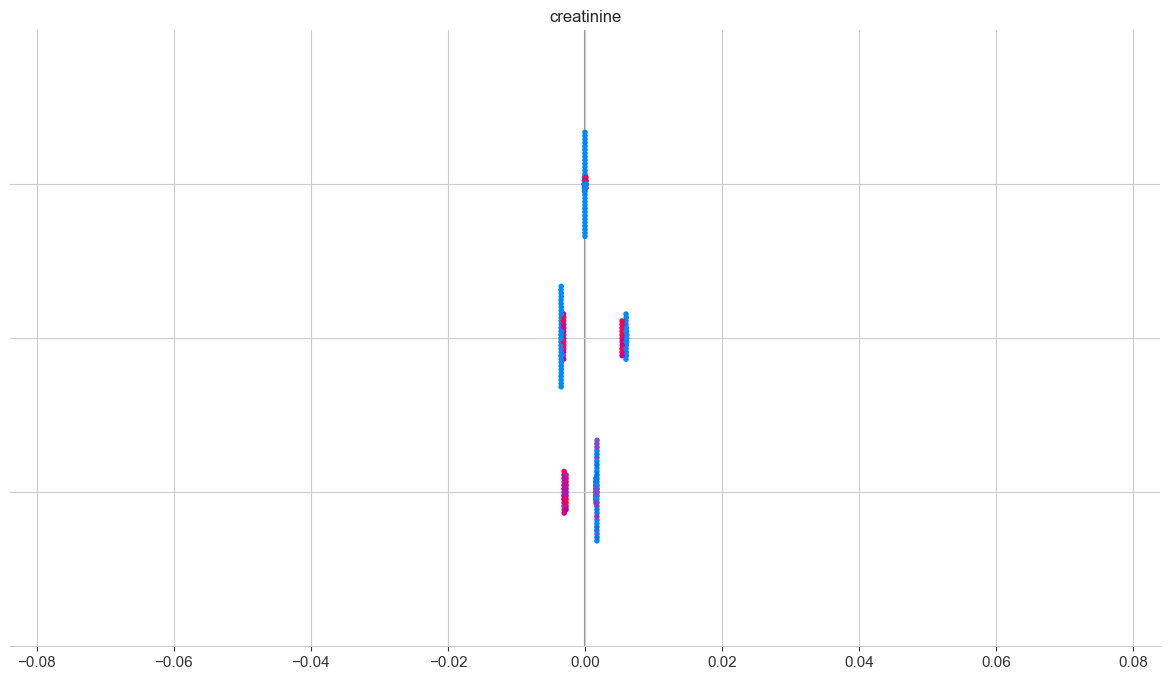

C:\Users\Surface\AppData\Local\Temp\ipykernel_7940\127808888.py:91: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)


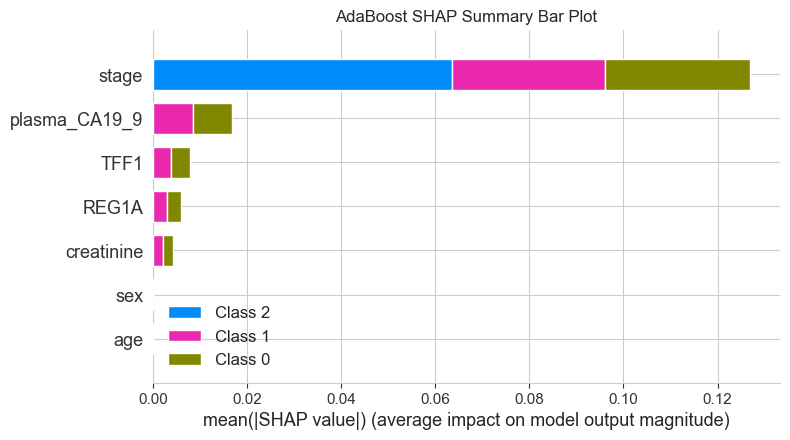

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

In [48]:
###grid ada---------------------
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, cohen_kappa_score, confusion_matrix, classification_report
from sklearn.ensemble import AdaBoostClassifier
from sklearn.preprocessing import LabelEncoder
import shap
import matplotlib.pyplot as plt

# Assuming new_X and new_y are already defined from your feature selection

# Split data
X_train, X_test, y_train, y_test = train_test_split(new_X, new_y, test_size=0.15, random_state=42, stratify=new_y)

# Encode target variable if it's categorical
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

# Define parameter grid for GridSearch
param_grid = {
    'n_estimators': [50, 100, 150],
    'learning_rate': [0.01, 0.1, 1.0],
    'algorithm': ['SAMME', 'SAMME.R']
}

# Set up KFold cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Initialize AdaBoostClassifier
ada = AdaBoostClassifier(random_state=42)

# Set up GridSearchCV
grid_search = GridSearchCV(
    estimator=ada,
    param_grid=param_grid,
    cv=kf,
    scoring='accuracy',  # or other scoring metrics
    n_jobs=-1,
    verbose=1
)

# Fit GridSearchCV to find best hyperparameters
grid_search.fit(X_train, y_train_encoded)

# Retrieve the best model
best_ada = grid_search.best_estimator_

# Optional: view best parameters
print("Best hyperparameters found:", grid_search.best_params_)

# Fit the best model (already fitted by GridSearchCV)
# Predict on test data
y_pred = best_ada.predict(X_test)
y_pred_proba = best_ada.predict_proba(X_test)

# Check shape of predicted probabilities
print("Predicted probabilities shape:", y_pred_proba.shape)

# Compute ROC AUC
roc_auc = roc_auc_score(y_test_encoded, y_pred_proba, multi_class='ovr')
print("ROC AUC:", roc_auc)

# Evaluate performance
print("Results for AdaBoost with GridSearch and KFold CV:")
print("Accuracy:", accuracy_score(y_test_encoded, y_pred))
print("Precision:", precision_score(y_test_encoded, y_pred, average='macro'))
print("Recall:", recall_score(y_test_encoded, y_pred, average='macro'))
print("F1 Score:", f1_score(y_test_encoded, y_pred, average='macro'))
print("Cohen's Kappa:", cohen_kappa_score(y_test_encoded, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test_encoded, y_pred))
print("Classification Report:\n", classification_report(y_test_encoded, y_pred))
print("-" * 50)

# SHAP analysis
print("SHAP analysis for AdaBoost with best hyperparameters:")

# Create a background dataset for KernelExplainer
background = X_train.sample(100, random_state=42)

explainer = shap.KernelExplainer(best_ada.predict_proba, background)

# Compute SHAP values
shap_values = explainer.shap_values(X_test, nsamples=100)

# Plot SHAP summary
shap.summary_plot(shap_values, X_test)

# Plot SHAP summary bar plot
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title("AdaBoost SHAP Summary Bar Plot")
plt.show()

# Dependence plots for top features
mean_abs_shap = np.abs(shap_values).mean(0)
top_features = np.argsort(mean_abs_shap)[-3:]
for feature_idx in top_features:
    shap.dependence_plot(feature_idx, shap_values, X_test)


In [ ]:
#3stacking
from sklearn.ensemble import StackingClassifier, AdaBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, cohen_kappa_score, precision_score, recall_score, confusion_matrix, classification_report, roc_auc_score
import shap
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import xgboost as xgb

# Split data into training and validation sets
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize base models
adaboost = AdaBoostClassifier(n_estimators=100, random_state=42)
xgboost = xgb.XGBClassifier(n_estimators=100, use_label_encoder=False, eval_metric='logloss', random_state=42)

# Create stacking classifier
stacking_clf = StackingClassifier(
    estimators=[
        ('ada', adaboost),
        ('xgb', xgboost)
    ],
    final_estimator=LogisticRegression()
)

# Train ensemble
start_time = time.time()
stacking_clf.fit(X_train, y_train)
training_time = time.time() - start_time
# Predict on validation set
start_time = time.time()
y_pred = stacking_clf.predict(X_valid)
y_pred_proba = stacking_clf.predict_proba(X_valid)
prediction_time = time.time() - start_time

y_pred_proba = stacking_clf.predict_proba(X_valid)
prediction_time = time.time() - start_time
print(f"Training Time: {training_time:.2f} seconds")
print(f"Prediction Time: {prediction_time:.2f} seconds")

# Evaluate ROC AUC
roc_auc = roc_auc_score(y_valid, y_pred_proba, multi_class='ovr')
print("ROC AUC:", roc_auc)

# Print metrics
print("Results for Stacking Ensemble:")
print("Accuracy:", accuracy_score(y_valid, y_pred))
print("Precision:", precision_score(y_valid, y_pred, average='macro'))
print("Recall:", recall_score(y_valid, y_pred, average='macro'))
print("F1 Score:", f1_score(y_valid, y_pred, average='macro'))
print("Cohen's Kappa:", cohen_kappa_score(y_valid, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_valid, y_pred))
print("Classification Report:\n", classification_report(y_valid, y_pred))
print("-" * 50)
# SHAP analysis
print("SHAP analysis for stacking_clf")

# Create a background dataset for KernelExplainer
background = X_train.sample(100, random_state=42)

explainer = shap.KernelExplainer(stacking_clf.predict_proba, background)

# Compute SHAP values
shap_values = explainer.shap_values(X_valid, nsamples=1


# Plot SHAP summary bar plot
shap.summary_plot(shap_values, X_valid, plot_type="bar", show=False)
plt.title("WOA_Ensemble SHAP Summary Bar Plot")
plt.show()



In [50]:
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    cohen_kappa_score,
    confusion_matrix,
    classification_report,
    precision_recall_curve,
    average_precision_score,
    
)
from sklearn.model_selection import train_test_split
import seaborn as sns
import scipy.stats as stats


# 1. MCC
# Correct usage
y_pred = stacking_clf.predict(X_valid)
print("Predictions shape:", y_pred.shape)
print("True labels shape:", y_valid.shape)

# Now compute MCC
from sklearn.metrics import matthews_corrcoef
mcc = matthews_corrcoef(y_valid, y_pred)
print("Matthews Correlation Coefficient (MCC):", mcc)

Predictions shape: (115,)
True labels shape: (115,)
Matthews Correlation Coefficient (MCC): 0.987054306629307


Permutation p-value for MCC: 0.0000
Permutation p-value for Cohen's Kappa: 0.0000


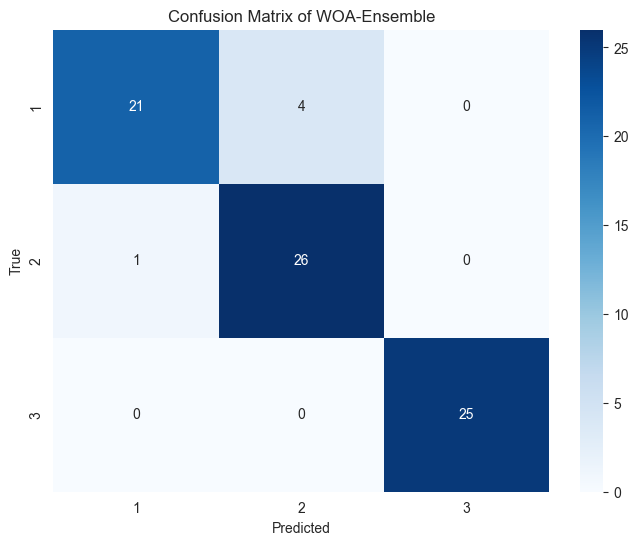

              Metric     Value  p-value MCC  p-value Kappa
0           Accuracy  0.935065          NaN            NaN
1  Precision (macro)  0.940404          NaN            NaN
2     Recall (macro)  0.934321          NaN            NaN
3   F1 Score (macro)  0.935299          NaN            NaN
4                MCC  0.904454          0.0            NaN
5      Cohen's Kappa  0.902383          NaN            0.0


In [60]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    cohen_kappa_score
)

# 4. Compute p-value for MCC via permutation test
def permutation_test_metric(y_true, y_pred, metric_func, n_permutations=1000):
    observed = metric_func(y_true, y_pred)
    permuted_scores = []
    for _ in range(n_permutations):
        y_perm = np.random.permutation(y_true)
        perm_score = metric_func(y_perm, y_pred)
        permuted_scores.append(perm_score)
    p_value = np.mean(np.array(permuted_scores) >= observed)
    return p_value

# Assuming y_test_encoded and y_pred are defined
# Example:
# y_test_encoded = ...
# y_pred = ...
# Also assuming 'mcc' is the MCC value already computed
# If not, compute it:
mcc = matthews_corrcoef(y_test_encoded, y_pred)

p_value_mcc = permutation_test_metric(y_test_encoded, y_pred, matthews_corrcoef)
print(f"Permutation p-value for MCC: {p_value_mcc:.4f}")

# Similarly, p-value for Cohen's Kappa
p_value_kappa = permutation_test_metric(y_test_encoded, y_pred, cohen_kappa_score)
print(f"Permutation p-value for Cohen's Kappa: {p_value_kappa:.4f}")

# 5. Confusion matrix heatmap
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test_encoded, y_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix of WOA-Ensemble')
plt.show()




In [66]:
import numpy as np
import lime
import lime.lime_tabular
import matplotlib.pyplot as plt

# Set the sample index
sample_idx = 0  # change as needed

# Initialize the LIME explainer
explainer_lime = lime.lime_tabular.LimeTabularExplainer(
    training_data=np.array(X_train),
    feature_names=X_train.columns,
    class_names=le.classes_,
    mode='classification'
)

# Ensure the data_row is a numpy array of feature values
data_row = X_test.iloc[sample_idx].values

# Generate explanation
exp = explainer_lime.explain_instance(
    data_row=data_row,
    predict_fn=stacking_clf.predict_proba,
    num_features=10
)

# Plot LIME explanation in notebook
exp.show_in_notebook(show_table=True)

# Add a title to the current matplotlib figure
plt.gcf().suptitle("WOA-Ensemble", fontsize=16, y=1.02)

# Save the explanation to an HTML file with the title included
html_path = f"lime_explanation_sample_{sample_idx}.html"
exp.save_to_file(html_path)
print(f"LIME explanation saved to {html_path}")


C:\Users\Surface\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but AdaBoostClassifier was fitted with feature names
  warnings.warn(


LIME explanation saved to lime_explanation_sample_0.html


<Figure size 640x480 with 0 Axes>

In [51]:
#stacking
from sklearn.ensemble import StackingClassifier, AdaBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, cohen_kappa_score, precision_score, recall_score, confusion_matrix, classification_report, roc_auc_score
import shap
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import xgboost as xgb

X_selected = X_resampled.iloc[:, selected_indices]

new_X = X_selected
new_y = y_resampled
# Split data into training and validation sets
X_train, X_valid, y_train, y_valid = train_test_split(new_X, new_y, test_size=0.2, random_state=42)
# Split data into training and validation sets
X_train, X_valid, y_train, y_valid = train_test_split(new_X, new_y, test_size=0.2, random_state=42)

# Initialize base models
adaboost = AdaBoostClassifier(n_estimators=100, random_state=42)
xgboost = xgb.XGBClassifier(n_estimators=100, use_label_encoder=False, eval_metric='logloss', random_state=42)

# Create stacking classifier
stacking_clf = StackingClassifier(
    estimators=[
        ('ada', adaboost),
        ('xgb', xgboost)
    ],
    final_estimator=LogisticRegression()
)

# Train ensemble
stacking_clf.fit(X_train, y_train)

# Predict on validation set
y_pred = stacking_clf.predict(X_valid)
y_pred_proba = stacking_clf.predict_proba(X_valid)

# Encode y if necessary (assuming y is already encoded)
# If not, ensure y is label encoded

# Compute ROC AUC (multi-class)
roc_auc = roc_auc_score(y_valid, y_pred_proba, multi_class='ovr')
print("ROC AUC:", roc_auc)

# Print detailed metrics
print("Results for Stacking Ensemble:")
print("Accuracy:", accuracy_score(y_valid, y_pred))
print("Precision:", precision_score(y_valid, y_pred, average='macro'))
print("Recall:", recall_score(y_valid, y_pred, average='macro'))
print("F1 Score:", f1_score(y_valid, y_pred, average='macro'))
print("Cohen's Kappa:", cohen_kappa_score(y_valid, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_valid, y_pred))
print("Classification Report:\n", classification_report(y_valid, y_pred))
print("-" * 50)

C:\Users\Surface\AppData\Roaming\Python\Python312\site-packages\xgboost\training.py:183: UserWarning: [19:35:32] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\Surface\AppData\Roaming\Python\Python312\site-packages\xgboost\training.py:183: UserWarning: [19:35:34] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\Surface\AppData\Roaming\Python\Python312\site-packages\xgboost\training.py:183: UserWarning: [19:35:35] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\Surface\AppData\Roaming\Python\Python312\site-packages\xgboost\training.py:183: UserWarning: [19:35:35] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\

ROC AUC: 0.9906368963937636
Results for Stacking Ensemble:
Accuracy: 0.9611650485436893
Precision: 0.9598054275473631
Recall: 0.9657784743991641
F1 Score: 0.9622739018087856
Cohen's Kappa: 0.9408216029876473
Confusion Matrix:
 [[28  1  0]
 [ 3 41  0]
 [ 0  0 30]]
Classification Report:
               precision    recall  f1-score   support

           1       0.90      0.97      0.93        29
           2       0.98      0.93      0.95        44
           3       1.00      1.00      1.00        30

    accuracy                           0.96       103
   macro avg       0.96      0.97      0.96       103
weighted avg       0.96      0.96      0.96       103

--------------------------------------------------


Selected feature indices: [0, 1, 2, 4, 5, 8]
Selected feature names: ['stage', 'creatinine', 'plasma_CA19_9', 'sex', 'LYVE1', 'REG1A']
Best Score: 0.08135593220338977


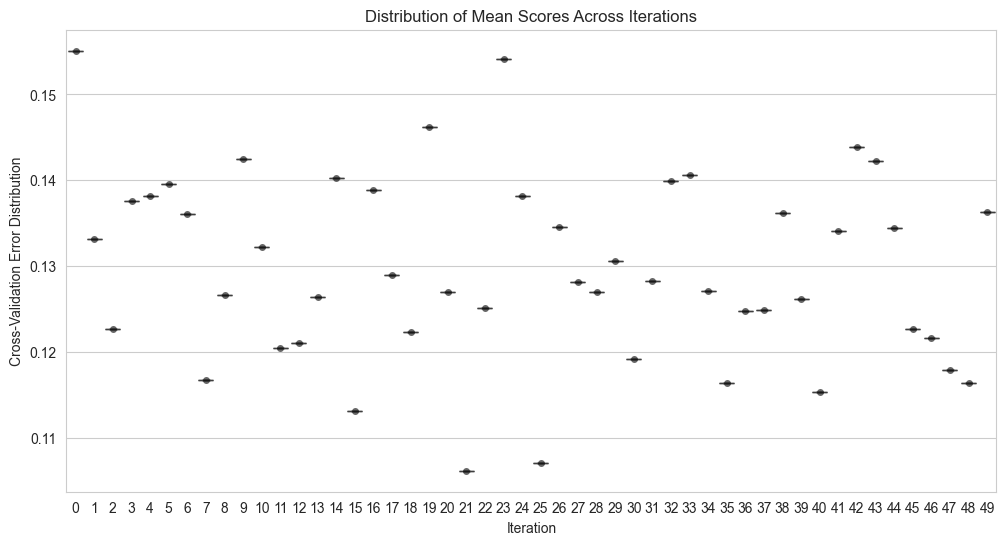

In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier


def evaluate_feature_subset(feature_mask):
    # Ensure at least one feature is selected
    if np.count_nonzero(feature_mask) == 0:
        return 1.0  # Worst score
    
    X_selected = X.loc[:, feature_mask == 1]
    classifier = DecisionTreeClassifier()
    scores = cross_val_score(classifier, X_selected, y, cv=5)
    return 1 - scores.mean()  # Minimize error

def enforce_feature_count(position, desired_count=6):
    """
    Ensures that the feature mask has exactly 'desired_count' features selected.
    """
    current_count = np.sum(position)
    indices = np.arange(len(position))
    if current_count > desired_count:
        # Too many features selected, turn off some randomly
        selected_indices = np.where(position == 1)[0]
        to_turn_off = np.random.choice(selected_indices, size=int(current_count - desired_count), replace=False)
        position[to_turn_off] = 0
    elif current_count < desired_count:
        # Too few features selected, turn on some randomly
        unselected_indices = np.where(position == 0)[0]
        to_turn_on = np.random.choice(unselected_indices, size=int(desired_count - current_count), replace=False)
        position[to_turn_on] = 1
    # If equal, do nothing
    return position

def pso_feature_selection(X, y, n_particles=20, max_iter=50, feature_count=6, w=0.72, c1=1.49, c2=1.49):
    """
    Implements PSO for feature selection.
    """
    dim = X.shape[1]
    # Initialize particles
    particles = np.zeros((n_particles, dim), dtype=int)
    velocities = np.random.uniform(-1, 1, size=(n_particles, dim))
    personal_best_positions = np.zeros((n_particles, dim), dtype=int)
    personal_best_scores = np.full(n_particles, np.inf)

    # Initialize particles with exactly 'feature_count' features
    for i in range(n_particles):
        indices = np.random.choice(dim, feature_count, replace=False)
        particles[i, indices] = 1

    # Initialize global best
    global_best_position = None
    global_best_score = np.inf

    # Store history for visualization
    history = []

    for t in range(max_iter):
        scores = []

        # Evaluate all particles
        for i in range(n_particles):
            fitness = evaluate_feature_subset(particles[i])
            scores.append(fitness)
            # Update personal best
            if fitness < personal_best_scores[i]:
                personal_best_scores[i] = fitness
                personal_best_positions[i] = particles[i].copy()

        # Update global best
        min_idx = np.argmin(personal_best_scores)
        if personal_best_scores[min_idx] < global_best_score:
            global_best_score = personal_best_scores[min_idx]
            global_best_position = personal_best_positions[min_idx].copy()

        # Store iteration info
        history.append({
            'iteration': t,
            'scores': scores,
            'features': [X.columns[i] for i in np.where(global_best_position == 1)[0]],
            'mean_score': np.mean(scores)
        })

        # Update velocities and positions
        for i in range(n_particles):
            r1 = np.random.rand(dim)
            r2 = np.random.rand(dim)

            # Velocity update
            velocities[i] = (
                w * velocities[i]
                + c1 * r1 * (personal_best_positions[i] - particles[i])
                + c2 * r2 * (global_best_position - particles[i])
            )

            # Update position based on velocity
            sigmoid = lambda x: 1 / (1 + np.exp(-x))
            prob = sigmoid(velocities[i])
            new_position = (np.random.rand(dim) < prob).astype(int)

            # Enforce exactly 'feature_count' features
            new_position = enforce_feature_count(new_position, feature_count)

            particles[i] = new_position

    # Convert history to DataFrame for plotting
    history_df = pd.DataFrame(history)
    return global_best_position, global_best_score, history_df

# Usage:
# Run PSO and get feature selection history
best_mask, best_score, history_df = pso_feature_selection(X, y, feature_count=6)

# Show selected feature indices and names
selected_indices = np.where(best_mask == 1)[0]
selected_feature_names = [X.columns[i] for i in selected_indices]
print("Selected feature indices:", list(selected_indices))
print("Selected feature names:", selected_feature_names)
print("Best Score:", best_score)

# Plot violin plots of cross-validation scores over iterations
plt.figure(figsize=(12, 6))
sns.boxplot(x='iteration', y='mean_score', data=history_df, whis=1.5, showcaps=True,
            boxprops={'facecolor':'None'}, showfliers=False)
sns.swarmplot(x='iteration', y='mean_score', data=history_df, color='k', alpha=0.6)
plt.xlabel('Iteration')
plt.ylabel('Cross-Validation Error Distribution')
plt.title('Distribution of Mean Scores Across Iterations')
plt.show()


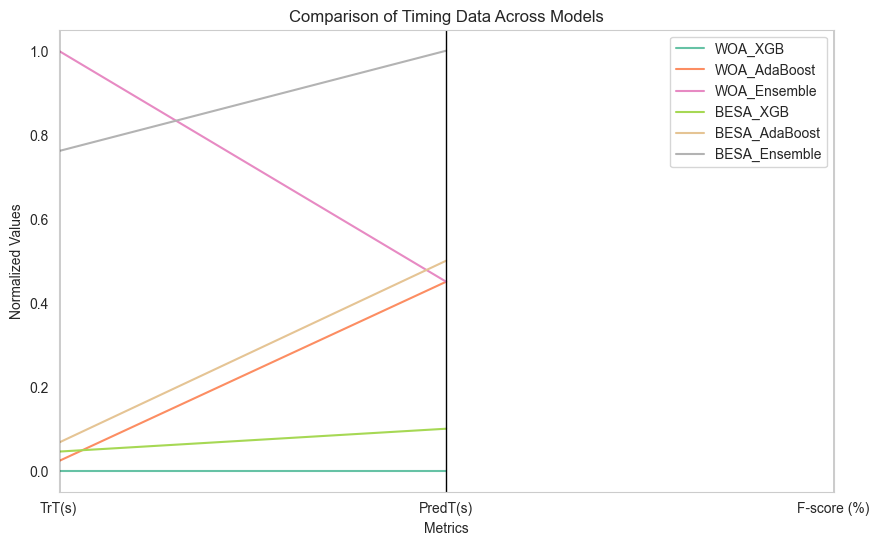

In [24]:
import numpy as np
import pandas as pd

# Create the data dictionary
data = {
    'Model': ['WOA_XGB', 'WOA_AdaBoost', 'WOA_Ensemble', 'BESA_XGB', 'BESA_AdaBoost', 'BESA_Ensemble'],
    'TrT(s)': [0.30, 0.44, 6.45, 0.58, 0.71, 4.98],
    'PredT(s)': [0.01, 0.10, 0.10, 0.03, 0.11, 0.21],
    'F-score (%)': [None, None, None, None, None, None]  # Placeholder if you want to include F-score
}

# Convert to DataFrame
df = pd.DataFrame(data)

import matplotlib.pyplot as plt
from pandas.plotting import parallel_coordinates

# For better visualization, normalize the data
from sklearn.preprocessing import MinMaxScaler

# Select the numerical columns for normalization
features = ['TrT(s)', 'PredT(s)']
scaler = MinMaxScaler()
df_scaled = df.copy()
df_scaled[features] = scaler.fit_transform(df[features])

# Add a 'Model' column for the class labels
df_scaled['Model'] = df['Model']

# Plot
plt.figure(figsize=(10,6))
parallel_coordinates(df_scaled, class_column='Model', colormap='Set2')
plt.title('Comparison of Timing Data Across Models')
plt.xlabel('Metrics')
plt.ylabel('Normalized Values')
plt.legend(loc='upper right')
plt.show()


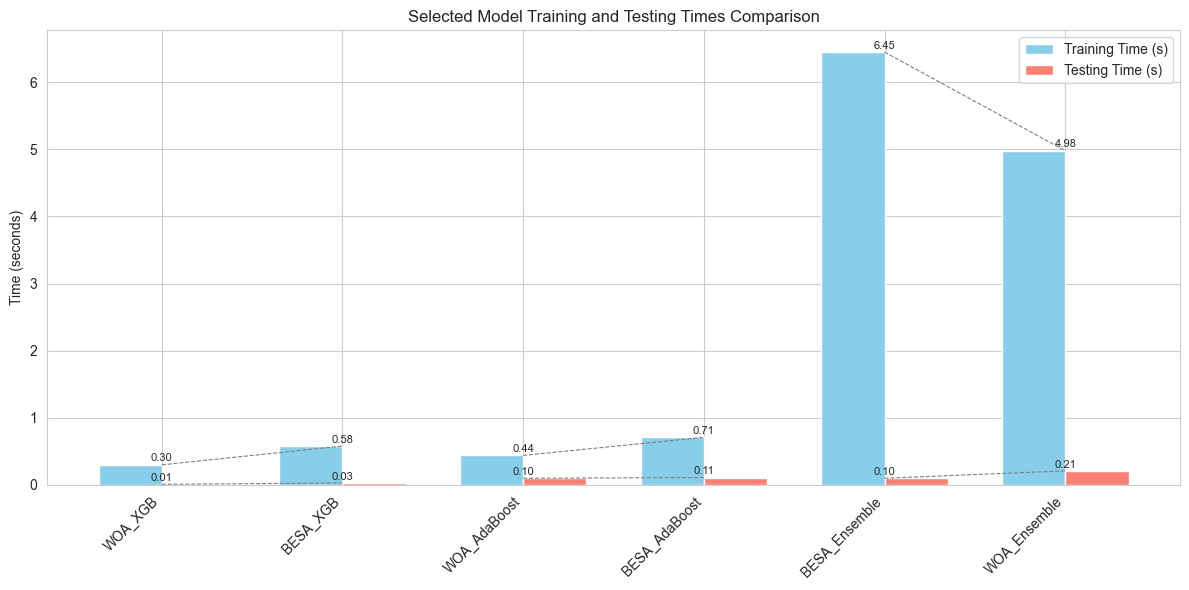

In [29]:
import matplotlib.pyplot as plt
import numpy as np

# Define the models for comparison
models = ['WOA_XGB', 'BESA_XGB', 'WOA_AdaBoost', 'BESA_AdaBoost', 'BESA_Ensemble', 'WOA_Ensemble']

# Corresponding training times
train_times = [0.30, 0.58, 0.44, 0.71, 6.45, 4.98]

# Corresponding testing times
test_times = [0.01, 0.03, 0.10, 0.11, 0.10, 0.21]

# Positions for each model
x = np.arange(len(models))
width = 0.35  # bar width

fig, ax = plt.subplots(figsize=(12, 6))

# Plot bars for training and testing times
ax.bar(x - width/2, train_times, width, label='Training Time (s)', color='skyblue')
ax.bar(x + width/2, test_times, width, label='Testing Time (s)', color='salmon')

# Optional: Plot lines connecting the same model's train and test times
for i in range(0, len(models), 2):
    # Connect train and test times for each comparison
    ax.plot([x[i], x[i+1]], [train_times[i], train_times[i+1]], color='gray', linestyle='--', linewidth=0.8)
    ax.plot([x[i], x[i+1]], [test_times[i], test_times[i+1]], color='gray', linestyle='--', linewidth=0.8)

# Set labels and titles
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=45, ha='right')
ax.set_ylabel('Time (seconds)')
ax.set_title('Selected Model Training and Testing Times Comparison')
ax.legend()

# Add data labels
for i in range(len(models)):
    # Labels for training times
    ax.text(i, train_times[i] + 0.02, f"{train_times[i]:.2f}", ha='center', va='bottom', fontsize=8)
    # Labels for testing times
    ax.text(i, test_times[i] + 0.02, f"{test_times[i]:.2f}", ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()
